Installing pre-trained transformers

In [3]:
!pip install transformers sentence-transformers

In [ ]:
Loading the CSV file

In [4]:
import pandas as pd

df = pd.read_csv("tickets.csv")

df.head()

,ticket_id,timestamp,customer_id,channel,message,product,order_value,customer_country,resolution_status
0,1,2026-05-01,C101,email,My order arrived damaged and the screen is cra...,Laptop,75000,India,Open
1,2,2026-05-01,C102,chat,Refund still not received after cancellation,Shoes,2500,USA,Pending
2,3,2026-05-02,C103,web,Delivery is delayed by more than a week,Headphones,5000,India,Open
3,4,2026-05-02,C104,email,Payment deducted twice from my account,Phone,30000,Canada,Resolved
4,5,2026-05-03,C105,chat,Unable to login to my account after password r...,Subscription,1000,UK,Open


In [ ]:
Loading the pre trained tranformers for analysis

In [5]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
Verifying the result

In [6]:
text = "This service is terrible"

result = sentiment_pipeline(text)

print(result)

[{'label': 'NEGATIVE', 'score': 0.9995855689048767}]


In [ ]:
Applying the loaded transformer on our dataset

In [7]:
df["sentiment"] = df["message"].apply(
    lambda x: sentiment_pipeline(x)[0]["label"]
)

df[["message", "sentiment"]]

,message,sentiment
0,My order arrived damaged and the screen is cra...,NEGATIVE
1,Refund still not received after cancellation,NEGATIVE
2,Delivery is delayed by more than a week,NEGATIVE
3,Payment deducted twice from my account,NEGATIVE
4,Unable to login to my account after password r...,NEGATIVE
5,Customer support is not responding at all,NEGATIVE
6,My package never arrived but status says deliv...,POSITIVE
7,Refund process is extremely slow,NEGATIVE
8,Received the wrong product instead of what I o...,NEGATIVE
9,App crashes every time I try to make payment,NEGATIVE


In [ ]:
Applying Zero Shot Classification for categorizing

In [8]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
CATEGORIES = [
    "Refund Issue",
    "Delivery Delay",
    "Damaged Product",
    "Payment Problem",
    "Login Issue",
    "Wrong Product",
    "Customer Support Complaint",
    "Technical Issue"
]

In [ ]:
Verifying the technique

In [10]:
text = "My order arrived broken and damaged"

result = classifier(text, CATEGORIES)

print(result["labels"][0])

Damaged Product


In [ ]:
Applying the same to our dataset

In [11]:
df["category"] = df["message"].apply(
    lambda x: classifier(x, CATEGORIES)["labels"][0]
)

In [12]:
df[["message", "category"]]

,message,category
0,My order arrived damaged and the screen is cra...,Damaged Product
1,Refund still not received after cancellation,Refund Issue
2,Delivery is delayed by more than a week,Delivery Delay
3,Payment deducted twice from my account,Payment Problem
4,Unable to login to my account after password r...,Login Issue
5,Customer support is not responding at all,Customer Support Complaint
6,My package never arrived but status says deliv...,Delivery Delay
7,Refund process is extremely slow,Refund Issue
8,Received the wrong product instead of what I o...,Wrong Product
9,App crashes every time I try to make payment,Payment Problem


In [ ]:
Identifying Business risk based on order value

In [13]:
df["business_risk"] = df.apply(
    lambda row: "High"
    if row["order_value"] > 20000 and row["sentiment"] == "NEGATIVE"
    else "Low",
    axis=1
)

In [14]:
df[[
    "message",
    "category",
    "sentiment",
    "order_value",
    "business_risk"
]]

,message,category,sentiment,order_value,business_risk
0,My order arrived damaged and the screen is cra...,Damaged Product,NEGATIVE,75000,High
1,Refund still not received after cancellation,Refund Issue,NEGATIVE,2500,Low
2,Delivery is delayed by more than a week,Delivery Delay,NEGATIVE,5000,Low
3,Payment deducted twice from my account,Payment Problem,NEGATIVE,30000,High
4,Unable to login to my account after password r...,Login Issue,NEGATIVE,1000,Low
5,Customer support is not responding at all,Customer Support Complaint,NEGATIVE,8000,Low
6,My package never arrived but status says deliv...,Delivery Delay,POSITIVE,25000,Low
7,Refund process is extremely slow,Refund Issue,NEGATIVE,45000,High
8,Received the wrong product instead of what I o...,Wrong Product,NEGATIVE,3500,Low
9,App crashes every time I try to make payment,Payment Problem,NEGATIVE,1500,Low


In [15]:
!pip install sentence-transformers

In [ ]:
Perfomring embedding and clustering

In [16]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

In [17]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
embeddings = embedding_model.encode(
    df["message"].tolist()
)

In [19]:
num_clusters = 4

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(embeddings)

In [20]:
df[["message", "cluster"]]

,message,cluster
0,My order arrived damaged and the screen is cra...,2
1,Refund still not received after cancellation,3
2,Delivery is delayed by more than a week,1
3,Payment deducted twice from my account,3
4,Unable to login to my account after password r...,0
5,Customer support is not responding at all,0
6,My package never arrived but status says deliv...,2
7,Refund process is extremely slow,3
8,Received the wrong product instead of what I o...,2
9,App crashes every time I try to make payment,0


In [21]:
df[["message", "cluster"]]

,message,cluster
0,My order arrived damaged and the screen is cra...,2
1,Refund still not received after cancellation,3
2,Delivery is delayed by more than a week,1
3,Payment deducted twice from my account,3
4,Unable to login to my account after password r...,0
5,Customer support is not responding at all,0
6,My package never arrived but status says deliv...,2
7,Refund process is extremely slow,3
8,Received the wrong product instead of what I o...,2
9,App crashes every time I try to make payment,0


In [22]:
for cluster_num in range(num_clusters):
    print(f"\nCluster {cluster_num}")
    print("-" * 40)

    cluster_messages = df[df["cluster"] == cluster_num]["message"]

    for msg in cluster_messages:
        print(msg)


Cluster 0
----------------------------------------
Unable to login to my account after password reset
Customer support is not responding at all
App crashes every time I try to make payment
The product stopped working within two days
Tracking information has not updated in days

Cluster 1
----------------------------------------
Delivery is delayed by more than a week
Delivery executive was rude and unprofessional

Cluster 2
----------------------------------------
My order arrived damaged and the screen is cracked
My package never arrived but status says delivered
Received the wrong product instead of what I ordered

Cluster 3
----------------------------------------
Refund still not received after cancellation
Payment deducted twice from my account
Refund process is extremely slow
I was charged but order was never confirmed
Need urgent refund for cancelled order


In [ ]:
Providing a geniric response based on the category to the user

In [23]:
def generate_response(category):

    responses = {
        "Refund Issue":
        "We apologize for the inconvenience. Our team is processing your refund and it will be completed shortly.",

        "Delivery Delay":
        "We are sorry for the delivery delay. Our logistics team is actively tracking your shipment.",

        "Damaged Product":
        "We regret that you received a damaged product. We can arrange a replacement or refund immediately.",

        "Payment Problem":
        "We apologize for the payment issue. Our billing team is reviewing the transaction.",

        "Login Issue":
        "We understand your concern. Please try resetting your password again or contact support for assistance.",

        "Wrong Product":
        "We are sorry for the incorrect delivery. We will arrange an exchange as soon as possible.",

        "Customer Support Complaint":
        "We sincerely apologize for your experience. Your feedback has been escalated to our support management team.",

        "Technical Issue":
        "We are currently investigating the technical issue and working towards a resolution."
    }

    return responses.get(
        category,
        "Thank you for contacting support. Our team will assist you shortly."
    )

In [24]:
df["suggested_response"] = df["category"].apply(
    generate_response
)

In [25]:
df[[
    "message",
    "category",
    "suggested_response"
]]

,message,category,suggested_response
0,My order arrived damaged and the screen is cra...,Damaged Product,We regret that you received a damaged product....
1,Refund still not received after cancellation,Refund Issue,We apologize for the inconvenience. Our team i...
2,Delivery is delayed by more than a week,Delivery Delay,We are sorry for the delivery delay. Our logis...
3,Payment deducted twice from my account,Payment Problem,We apologize for the payment issue. Our billin...
4,Unable to login to my account after password r...,Login Issue,We understand your concern. Please try resetti...
5,Customer support is not responding at all,Customer Support Complaint,We sincerely apologize for your experience. Yo...
6,My package never arrived but status says deliv...,Delivery Delay,We are sorry for the delivery delay. Our logis...
7,Refund process is extremely slow,Refund Issue,We apologize for the inconvenience. Our team i...
8,Received the wrong product instead of what I o...,Wrong Product,We are sorry for the incorrect delivery. We wi...
9,App crashes every time I try to make payment,Payment Problem,We apologize for the payment issue. Our billin...


In [ ]:
Visualization for business analysis

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
category_counts = df["category"].value_counts()

print(category_counts)

category
Damaged Product               3
Refund Issue                  3
Delivery Delay                3
Payment Problem               2
Login Issue                   1
Customer Support Complaint    1
Wrong Product                 1
Technical Issue               1
Name: count, dtype: int64


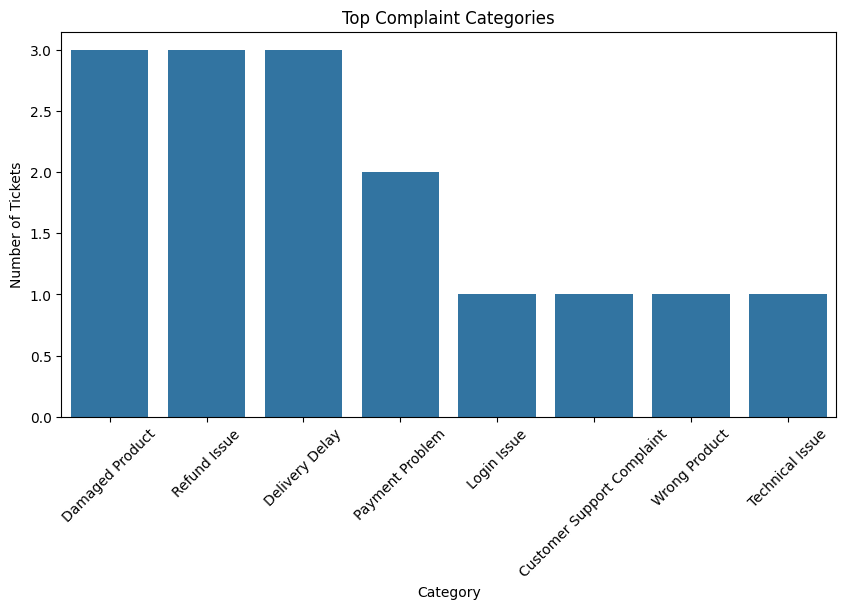

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.xticks(rotation=45)
plt.title("Top Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")

plt.show()

In [29]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
NEGATIVE    14
POSITIVE     1
Name: count, dtype: int64


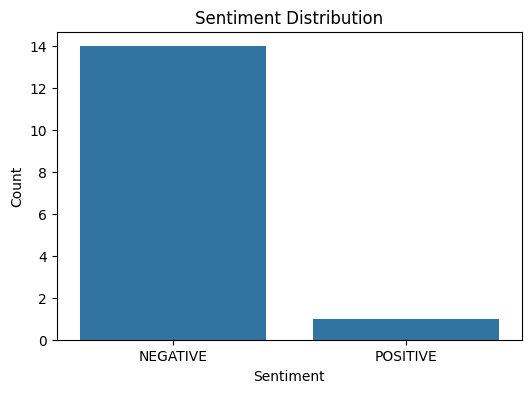

In [30]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [31]:
high_risk = df[df["business_risk"] == "High"]

high_risk[[
    "message",
    "category",
    "order_value"
]]

,message,category,order_value
0,My order arrived damaged and the screen is cra...,Damaged Product,75000
3,Payment deducted twice from my account,Payment Problem,30000
7,Refund process is extremely slow,Refund Issue,45000
12,I was charged but order was never confirmed,Delivery Delay,82000


In [32]:
revenue_impact = df.groupby("category")[
    "order_value"
].sum().sort_values(ascending=False)

print(revenue_impact)

category
Delivery Delay                112000
Damaged Product               101000
Refund Issue                   51500
Payment Problem                31500
Technical Issue                18000
Customer Support Complaint      8000
Wrong Product                   3500
Login Issue                     1000
Name: order_value, dtype: int64


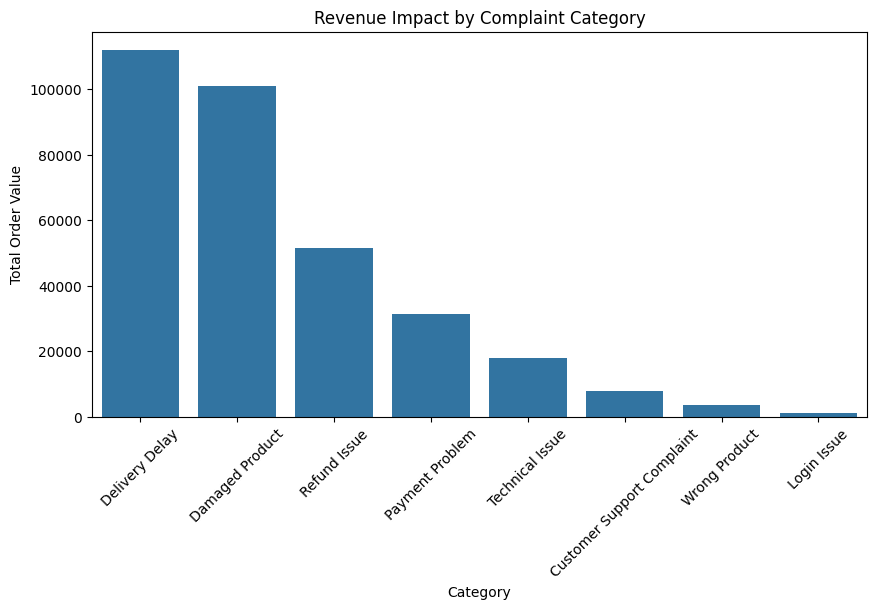

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=revenue_impact.index,
    y=revenue_impact.values
)

plt.xticks(rotation=45)

plt.title("Revenue Impact by Complaint Category")
plt.xlabel("Category")
plt.ylabel("Total Order Value")

plt.show()

In [ ]:
Drawing business insights 

In [34]:
top_issue = category_counts.idxmax()

most_impacted = revenue_impact.idxmax()

negative_percent = round(
    (
        len(df[df["sentiment"] == "NEGATIVE"])
        / len(df)
    ) * 100,
    2
)

print("BUSINESS INSIGHTS")
print("-" * 40)

print(f"Top recurring issue: {top_issue}")

print(f"Highest revenue impact: {most_impacted}")

print(f"Negative sentiment tickets: {negative_percent}%")

BUSINESS INSIGHTS
----------------------------------------
Top recurring issue: Damaged Product
Highest revenue impact: Delivery Delay
Negative sentiment tickets: 93.33%


In [ ]:
Data Storage

In [35]:
import sqlite3

conn = sqlite3.connect("support_tickets.db")

df.to_sql(
    "tickets",
    conn,
    if_exists="replace",
    index=False
)

print("Data stored successfully in SQLite database")

Data stored successfully in SQLite database


In [ ]:
Saving the processed file for making the dashboard

In [36]:
df.to_csv(
    "processed_tickets.csv",
    index=False
)